In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"

import numpy as np
import tensorflow as tf
from tabulate import tabulate
from tensorflow.python.client import device_lib
from tqdm import tqdm
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import Counter, deque
from tqdm import tqdm
import random
import copy
from PIL import Image
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import time
from collections import defaultdict


2025-10-20 17:14:35.448266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760960675.460214  435447 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760960675.464125  435447 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760960675.473808  435447 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760960675.473826  435447 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760960675.473828  435447 computation_placer.cc:177] computation placer alr

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:

def print_gpu_details():
    """Prints all available GPUs in a formatted table with key details"""
    # Get list of all devices
    devices = device_lib.list_local_devices()
    gpu_details = []
    
    for device in devices:
        if device.device_type == 'GPU':
            # Extract details from the device description string
            desc = device.physical_device_desc
            details = {
                'Device ID': device.name.split(':')[-1],
                'Name': desc.split('name: ')[1].split(',')[0] if 'name: ' in desc else 'Unknown',
                'Memory (GB)': f"{device.memory_limit / (1024**3):.2f}",
                'PCI Bus ID': desc.split('pci bus id: ')[1].split(',')[0] if 'pci bus id: ' in desc else 'Unknown',
                'GFX Version': os.environ.get('HSA_OVERRIDE_GFX_VERSION', 'Native')
            }
            gpu_details.append(details)
    
    # Print table if GPUs found
    if gpu_details:
        print("\n" + "="*85)
        print("ACTIVE GPU CONFIGURATION".center(85))
        print("="*85)
        print(tabulate(gpu_details, headers="keys", tablefmt="grid"))
        print("="*85+ "\n")
    else:
        print("No GPU devices found!")


def configure_gpu(vram_limit):
    """Configure GPU settings with optional GFX override"""
    
    # Verify GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Limit VRAM on the specified GPU
            
            for gid in range(len(gpus)):
                
                tf.config.experimental.set_virtual_device_configuration(
                    gpus[gid],
                    [tf.config.experimental.VirtualDeviceConfiguration(
                        memory_limit=vram_limit[gid] * 1024)]  # Convert GB to MB
                )
                print(f"GPU {gid} VRAM limited to {vram_limit[gid]}GB")
                
        except RuntimeError as e:
            print(f"Error setting VRAM limit: {e}")
    
    if not gpus:
        raise RuntimeError(f"No GPU found")
    
    for gid in range(len(gpus)):
        print(f"Configured GPU {gid}: {tf.config.experimental.get_device_details(gpus[gid])}") 
        
        with tf.device('/GPU:'+str(gid)):  # Force GPU usage
            x = tf.ones((1, 1))    # Smallest possible tensor
            y = x + 1              # Simple operation
            y.numpy()              # Force execution

In [3]:
VRAM = [3.0]

configure_gpu(VRAM)

print_gpu_details()

GPU 0 VRAM limited to 3.0GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}

                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |             3 | 0000:01:00.0 | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+



I0000 00:00:1760960679.915640  435447 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3072 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1760960679.965717  435447 gpu_device.cc:2019] Created device /device:GPU:0 with 3072 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
def load_calibration(file_path):
    
    # {
    #     'cam0': array([[2945.377,    0.   , 1284.862],
    #                 [   0.   , 2945.377,  954.52 ],
    #                 [   0.   ,    0.   ,    1.   ]]),
    #     'cam1': array([[2945.377,    0.   , 1455.543],
    #                 [   0.   , 2945.377,  954.52 ],
    #                 [   0.   ,    0.   ,    1.   ]]),
    #     'doffs': 170.681,
    #     'baseline': 178.232,
    #     'width': 2864,
    #     'height': 1924,
    #     'ndisp': 260,
    #     'isint': 0,
    #     'vmin': 32,
    #     'vmax': 224
    # }
        
    calib = {}
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
                
            # Split key and value
            if '=' in line:
                key, value = line.split('=', 1)
                key = key.strip()
                value = value.strip()
                
                # Handle matrix values (e.g., cam0=[...])
                if value.startswith('[') and value.endswith(']'):
                    matrix_str = value[1:-1]
                    # Split rows
                    rows = matrix_str.split(';')
                    matrix = []
                    for row in rows:
                        # Convert each row to float values
                        matrix.append([float(x) for x in row.split()])
                    value = np.array(matrix)
                
                # Handle scalar values
                else:
                    try:
                        # Try to convert to float if possible
                        value = float(value)
                        # Convert to int if no decimal part
                        if value.is_integer():
                            value = int(value)
                    except ValueError:
                        pass  # Keep as string if conversion fails
                
                calib[key] = value
                
    return calib

In [5]:

def load_image_to_rgb(image_path):
    """Load an image from path and return as RGB numpy array."""
    img = Image.open(image_path)
    return np.array(img.convert('RGB'))

In [6]:
def rgb_to_mono(img_array):
    """Convert RGB image array to luminance (grayscale) using standard weights."""
    if len(img_array.shape) == 2:
        return img_array  # Already grayscale
    gray = np.dot(img_array[..., :3], [0.33, 0.33, 0.33])
    return gray.astype(np.int_)

In [7]:

def load_pfm_disparity(file_path):
    
    try:
        with open(file_path, 'rb') as f:
            # Read header lines
            header = f.readline().decode('ascii').strip()
            dimensions = f.readline().decode('ascii').strip()
            scale = f.readline().decode('ascii').strip()
            
            # Parse dimensions
            width, height = map(int, dimensions.split())
            
            # Parse scale and determine endianness
            scale_factor = float(scale)
            little_endian = scale_factor < 0
            
            # Read binary data with correct endianness
            if little_endian:
                data = np.fromfile(f, dtype='<f4')  # Little-endian float32
            else:
                data = np.fromfile(f, dtype='>f4')  # Big-endian float32
            
            # Reshape the data
            expected_size = width * height
            if len(data) == expected_size:
                disparity_matrix = data.reshape((height, width))
            elif len(data) == expected_size * 3:
                # Color image - take mean of RGB channels
                disparity_matrix = data.reshape((height, width, 3)).mean(axis=2)
            else:
                raise ValueError(f"Unexpected data size: got {len(data)}, expected {expected_size}")
            
            disparity_matrix = disparity_matrix[::-1]
            
            disparity_matrix = np.where(disparity_matrix==np.inf,-1,disparity_matrix)
            
            return disparity_matrix
            
    except Exception as e:
        print(f"Error reading PFM file: {e}")
        raise

In [8]:
import numpy as np

def crop_array(array, target_shape):
    
    target_height, target_width = target_shape
    
    arr_shape = array.shape
    
    current_height, current_width = arr_shape[0],arr_shape[1]
    
    start_y = (current_height - target_height) // 2
    start_x = (current_width - target_width) // 2
    end_y = start_y + target_height
    end_x = start_x + target_width
    
    cropped_array = array[start_y:end_y, start_x:end_x]
    
    return cropped_array

In [9]:

def display_image_array(img_array):
    
    # print(img_array.shape)

    
    """Display a numpy image array (2D or 3D) without axes."""
    plt.figure()
    if len(img_array.shape) == 3:  # RGB image
        plt.imshow(img_array)
    else:  # Grayscale
        plt.imshow(img_array, cmap='gray')
    plt.axis('off')
    plt.show()

In [10]:


def resize_image_array(image_array, scale_factor):
    # Convert array to PIL Image
    if len(image_array.shape) == 2:
        # Grayscale image
        img = Image.fromarray(image_array)
    elif len(image_array.shape) == 3:
        # RGB/RGBA image
        img = Image.fromarray(image_array.astype('uint8'))
    else:
        raise ValueError("Input array must be 2D (grayscale) or 3D (color)")
    
    # Calculate new dimensions
    width, height = img.size
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)
    
    # Resize using Lanczos resampling (high quality)
    resized_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # Convert back to numpy array
    resized_array = np.array(resized_img)
    
    # Preserve original dtype for grayscale
    if len(image_array.shape) == 2:
        resized_array = resized_array.astype(image_array.dtype)
    
    return resized_array

In [11]:
def plot_disp_array(data_array,colourbar=False):
    
    # print(data_array.shape)
    
    plt.figure(figsize=(6, 6))
    img = plt.imshow(data_array, cmap='viridis')
    plt.axis('off')
    if colourbar:
        cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
        cbar.set_label('Value Scale', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

In [12]:
def plot_viridis_matrix(matrix):
    # Visualize results
    plt.figure(figsize=(12, 5))
    plt.imshow(matrix, cmap='viridis')
    plt.title('Matrix')
    plt.colorbar()

In [13]:
def display_six_arrays_with_cbar(img1, img2, img3, img4, disp1, disp2, 
                                show_colorbar=False, figsize=(15, 10)):
    """
    Display 6 arrays in a 3x2 grid layout with optional colorbars for disparity maps.
    
    Parameters:
    img1, img2, img3, img4: Image arrays (2D or 3D RGB)
    disp1, disp2: Disparity arrays (2D, displayed with viridis colormap)
    show_colorbar: Whether to show colorbars for disparity maps
    figsize: Tuple specifying the figure size (width, height)
    """
    if show_colorbar:
        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    else:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    
    # First row: img1 and img2
    if len(img1.shape) == 3:
        axes[0, 0].imshow(img1)
    else:
        axes[0, 0].imshow(img1, cmap='gray')
    axes[0, 0].axis('off')
    
    if len(img2.shape) == 3:
        axes[0, 1].imshow(img2)
    else:
        axes[0, 1].imshow(img2, cmap='gray')
    axes[0, 1].axis('off')
    
    # Second row: img3 and img4
    if len(img3.shape) == 3:
        axes[1, 0].imshow(img3)
    else:
        axes[1, 0].imshow(img3, cmap='gray')
    axes[1, 0].axis('off')
    
    if len(img4.shape) == 3:
        axes[1, 1].imshow(img4)
    else:
        axes[1, 1].imshow(img4, cmap='gray')
    axes[1, 1].axis('off')
    
    # Third row: disp1 and disp2
    im1 = axes[2, 0].imshow(disp1, cmap='viridis')
    axes[2, 0].axis('off')
    if show_colorbar:
        plt.colorbar(im1, ax=axes[2, 0], fraction=0.046, pad=0.04)
    
    im2 = axes[2, 1].imshow(disp2, cmap='viridis')
    axes[2, 1].axis('off')
    if show_colorbar:
        plt.colorbar(im2, ax=axes[2, 1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore




In [15]:
# .........................
# Image Locations
# .........................

image_org_path="/mnt/Personal/Projects/Depth_Reconstruction/Test_Folder/stereo_test/"
# org_path="G:/Projects/Depth_Reconstruction/Test_Folder/stereo_test/"

object_name="Backpack"

test_input_path=image_org_path+"test_images/"+object_name+"/"
test_output_path=image_org_path+"test_outputs/"
test_3d_path=image_org_path+"test_3d/"

left_path = test_input_path+"im0.png"
right_path = test_input_path+"im1.png"
calib_path = test_input_path+"calib.txt"
left_truth_path = test_input_path+"disp0.pfm"
right_truth_path = test_input_path+"disp1.pfm"

resize_fraction = 1
resize_factor = 1/resize_fraction


calib = load_calibration(calib_path)

rgb_l = load_image_to_rgb(left_path)
rgb_r = load_image_to_rgb(right_path)

rgb_l = resize_image_array(rgb_l,resize_factor)
rgb_r = resize_image_array(rgb_r,resize_factor)

gray_l = rgb_to_mono(rgb_l)
gray_r = rgb_to_mono(rgb_r)

truth_l = load_pfm_disparity(left_truth_path)
truth_r = load_pfm_disparity(right_truth_path)

truth_l = resize_image_array(truth_l,resize_factor)
truth_l = truth_l//resize_fraction
truth_r = resize_image_array(truth_r,resize_factor)
truth_r = truth_r//resize_fraction

In [16]:
import numpy as np

def extract_patches_and_strips(image, patch_shape, Dmax,patch_skip,multiple):
    height, width = image.shape
    patch_h, patch_w = patch_shape
    
    size = int(((height - patch_h + 1)//patch_skip[0] + 1)*((width - patch_w + 1)//patch_skip[1] + 1))
    new_size = int(np.ceil(size/multiple)*multiple+1)
    
    patch_array = np.zeros(shape=(new_size,patch_shape[0],patch_shape[1]),dtype=np.uint8)
    strip_array = np.zeros(shape=(new_size,patch_shape[0],patch_shape[1]+Dmax),dtype=np.uint8)
    
    counter = 0
    
    position_list = []
    
    # Iterate over all possible top-left positions for patches
    for y in tqdm(range(0,height - patch_h + 1,patch_skip[0])):
        for x in range(0,width - patch_w + 1,patch_skip[1]):
            
            # Extract the patch
            patch = image[y:y+patch_h, x:x+patch_w]
            
            flip = False
            strip = None
            
            # Try to extract strip with -Dmax (left side)
            if x - Dmax >= 0:
                # Extract strip from left side
                strip_x_start = x - Dmax
                strip_x_end = x + patch_w
                strip = image[y:y+patch_h, strip_x_start:strip_x_end]
                flip = False
            # If left side not available, try +Dmax (right side)
            elif x + patch_w + Dmax <= width:
                # Extract strip from right side
                strip_x_start = x
                strip_x_end = x + patch_w + Dmax
                strip = image[y:y+patch_h, strip_x_start:strip_x_end]
                flip = True
            else:
                # Skip if neither side is available
                continue
            
            # If we found a valid strip
            if strip is not None:
                # Apply flipping if needed
                if flip:
                    patch = np.fliplr(patch)
                    strip = np.fliplr(strip)
                
                # Add to lists
                position_list.append([y, x, flip])
                patch_array[counter] = patch
                strip_array[counter] = strip
                
                counter+=1
            
    position_array = np.array(position_list, dtype=object)
    
    return position_array, patch_array, strip_array



In [17]:
import numpy as np

def pad_to_whole(arr, multiple, pad_value=0):
    current_shape = arr.shape
    new_shape = list(current_shape)  # Start with original shape
    
    # Only modify the first dimension (axis 0)
    first_dim = current_shape[0]
    remainder = first_dim % multiple
    if remainder == 0:
        # Already a multiple, return copy
        new_shape[0] = new_shape[0]  + 1
    else:
        new_shape[0] = first_dim + (multiple - remainder)  + 1 
    
    # Create new array and copy original data
    padded_arr = np.full(new_shape, pad_value, dtype=arr.dtype)
    
    # Create slicing tuple - take all of original data in first dimension
    slices = [slice(0, first_dim)] + [slice(None)] * (arr.ndim - 1)
    padded_arr[tuple(slices)] = arr
    
    return padded_arr

In [18]:
patch_shape = (50, 50)
Dmax = 800   
patch_skip = (5,5)
BATCH_SIZE = 128

position_array, left_patches, right_strips = extract_patches_and_strips(gray_l, patch_shape, Dmax,patch_skip,BATCH_SIZE)

target = len(left_patches)

print(target)
print(position_array.shape)
print(left_patches.shape)
print(right_strips.shape)


model_location = "/mnt/Extra/Project_Storage/stereo_ML_dataset/model/"

100%|██████████| 394/394 [00:04<00:00, 81.36it/s]

228225
(228126, 3)
(228225, 50, 50)
(228225, 50, 850)


In [19]:

# -------------------------
# Create testing generator (no median_disp)
# -------------------------
from tensorflow.keras.utils import Sequence
import numpy as np

# -------------------------
# Test data generator (no median disparity)
# -------------------------
class TestGenerator(Sequence):
    def __init__(self, left_mm, right_mm, indices, batch_size=8, patch_shape=(0,0), Dmax=800):
        self.left_mm = left_mm
        self.right_mm = right_mm
        self.indices = indices
        self.batch_size = batch_size
        self.patch_shape = patch_shape
        self.Dmax = Dmax

    def __len__(self):
        return len(self.indices)//self.batch_size 

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min((idx+1) * self.batch_size, len(self.indices))
        batch_idx = self.indices[start:end]

        Xl = np.expand_dims(self.left_mm[batch_idx][:, :self.patch_shape[0], :self.patch_shape[1]], axis=-1)/255.0
        Xr = np.expand_dims(self.right_mm[batch_idx][:, :self.patch_shape[0], :self.patch_shape[1]+self.Dmax], axis=-1)/255.0

        # Return dummy outputs (zeros) just to satisfy Keras
        dummy_y = np.zeros((len(batch_idx), 1), dtype='float32')

        return (Xl.astype('float32'), Xr.astype('float32')), dummy_y



idx_test = np.arange(target)

test_gen = TestGenerator(
    left_patches, 
    right_strips, 
    idx_test, 
    batch_size=BATCH_SIZE, 
    patch_shape=patch_shape, 
    Dmax=Dmax
)



In [20]:


# -------------------------
# LOAD TRAINED MODEL
# -------------------------
model_path = model_location+"model_epoch_100.keras"  # or model_final.keras
model = tf.keras.models.load_model(model_path)
print(f"Loaded model from {model_path}")

# model.summary()

# Load
# loaded_history = np.load(model_location+"history.npy",allow_pickle=True).item()
# print(loaded_history.keys())   # e.g. dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

# import matplotlib.pyplot as plt

# plt.plot(loaded_history['loss'], label='Train Loss')
# plt.plot(loaded_history['val_loss'], label='Val Loss')
# plt.plot(loaded_history['mse'], label='Train MSE')
# plt.plot(loaded_history['val_mse'], label='Val MSE')
# plt.legend()
# plt.show()


ValueError: File not found: filepath=/mnt/Extra/Project_Storage/stereo_ML_dataset/model/model_epoch_100.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
predicted_disparity = model.predict(test_gen, verbose=1).flatten() * Dmax
print(len(predicted_disparity))

/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1760960537.295236  433866 service.cc:152] XLA service 0x76198c00e5b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760960537.295258  433866 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-20 17:12:17.320710: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760960537.423773  433866 cuda_dnn.cc:529] Loaded cuDNN version 90701


  6/428 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step 

I0000 00:00:1760960540.328715  433866 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


428/428 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step
54784


Processing patches: 100%|██████████| 48000/48000 [00:00<00:00, 139782.27it/s]


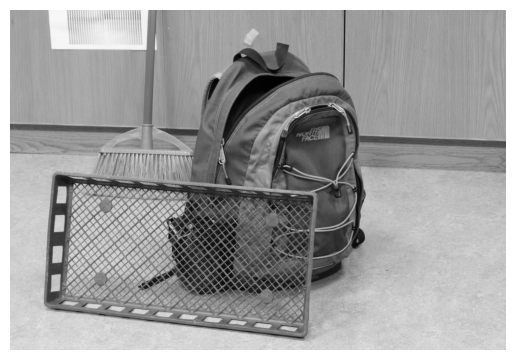

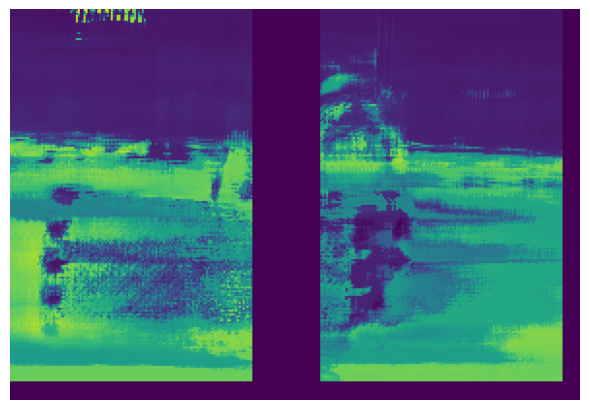

In [ ]:
def create_averaged_disparity_map_optimized(position_array, disp_list, patch_shape, image_shape):
    """
    Optimized version using vectorized operations.
    """
    height, width = image_shape
    patch_h, patch_w = patch_shape
    
    # Initialize arrays
    disparity_array = np.zeros(image_shape, dtype=np.float32)
    counter_array = np.zeros(image_shape, dtype=np.int16)
    
    for i in tqdm(range(len(position_array)), desc="Processing patches"):
        y, x, flip = position_array[i]
        disp_value = disp_list[i]
        
        # Calculate the actual patch boundaries (handling edge cases)
        y_start = y
        y_end = min(y + patch_h, height)
        x_start = x
        x_end = min(x + patch_w, width)
        
        # Get the patch region
        patch_region = disparity_array[y_start:y_end, x_start:x_end]
        count_region = counter_array[y_start:y_end, x_start:x_end]
        
        # Update using vectorized operations
        # new_value = (old_value * old_count + disp_value) / (old_count + 1)
        mask = count_region > 0
        patch_region[mask] = (patch_region[mask] * count_region[mask] + disp_value) / (count_region[mask] + 1)
        patch_region[~mask] = disp_value
        
        # Update counter
        counter_array[y_start:y_end, x_start:x_end] += 1
    
    # Convert to int16 for final output
    disparity_array = disparity_array.astype(np.int16)
    
    return disparity_array

disp_patch_shape = (5,5)

disparity_array = create_averaged_disparity_map_optimized(position_array, predicted_disparity, disp_patch_shape, gray_l.shape)

display_image_array(gray_l)
plot_disp_array(disparity_array)